In [18]:
FILE_PATH = Path('../output/structured_data.xlsx')
df = pd.read_excel(FILE_PATH)

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fungo_strip(
    *,
    analises: list[str],
    bases: tuple[str, str] = ("A", "B"),
    fungos_order: list[str] | None = None,
    y_col: str = "valor",
    pair_keys: tuple[str, ...] = ("concentracao", "dia"),  # matched within each fungo+analise
    agg: str = "mean",  # how to collapse replicates before delta
    alpha: float = 0.85,
    size: int = 28,
    jitter: float = 0.10,
    dodge: float = 0.22,
    seed: int = 42,
    show: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Single categorical strip/jitter plot with DELTAS:
      - x categories: fungo
      - y: delta = (base+'I') - base, e.g. AI-A and BI-B
      - points: pooled across all concentrations/days inside the selected analyses

    Required columns: fungo, sistema, analise, valor, plus any pair_keys you use.
    """
    required = {"fungo", "sistema", "analise", y_col, *pair_keys}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    if not analises:
        raise ValueError("analises must be a non-empty list, e.g. ['IGN','IER'].")

    rng = np.random.default_rng(seed)

    d = df.copy()
    d["fungo"] = d["fungo"].astype(str).str.strip()
    d["sistema"] = d["sistema"].astype(str).str.strip()
    d["analise"] = d["analise"].astype(str).str.strip()
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    wanted = {str(a).strip() for a in analises}

    # Keep only rows relevant to computing deltas (A/AI and B/BI, etc.)
    needed_systems = []
    for b in bases:
        needed_systems.extend([b, f"{b}I"])

    d = d[
        d["analise"].isin(wanted)
        & d["sistema"].isin(needed_systems)
        & d[y_col].notna()
    ].copy()

    if d.empty:
        raise ValueError(
            f"No rows after filtering to analises={sorted(wanted)} and sistemas={needed_systems}."
        )

    # Normalize common fungus spelling variants (practical)
    def norm_fungo(s: str) -> str:
        lo = s.lower()
        if "aspergill" in lo: return "Aspergillus"
        if "saccharom" in lo: return "Saccharomyces"
        if "penicill" in lo: return "Penicillium"
        if "candida" in lo: return "Candida"
        return s

    d["fungo_norm"] = d["fungo"].map(norm_fungo)

    # Collapse replicates (if any) so each (fungo, analise, pair_keys..., sistema) is single-valued
    group_cols = ["fungo_norm", "analise", *pair_keys, "sistema"]

    if agg == "mean":
        d_agg = d.groupby(group_cols, observed=True)[y_col].mean().reset_index()
    elif agg == "median":
        d_agg = d.groupby(group_cols, observed=True)[y_col].median().reset_index()
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Pivot to compute deltas
    idx_cols = ["fungo_norm", "analise", *pair_keys]
    pv = d_agg.pivot_table(index=idx_cols, columns="sistema", values=y_col, aggfunc="first")

    delta_frames = []
    for b in bases:
        inoc = f"{b}I"
        if b not in pv.columns or inoc not in pv.columns:
            continue
        delta = (pv[inoc] - pv[b]).dropna()
        if delta.empty:
            continue
        tmp = delta.reset_index().rename(columns={0: y_col, delta.name: y_col})
        tmp["delta_base"] = b  # indicates whether it's AI-A (A) or BI-B (B)
        delta_frames.append(tmp)

    if not delta_frames:
        raise ValueError(
            "Could not compute any deltas. Likely missing paired systems (A and AI, or B and BI) "
            "for the same (fungo, analise, concentracao, dia)."
        )

    dd = pd.concat(delta_frames, ignore_index=True)

    # Category order
    if fungos_order is None:
        preferred = ["Candida", "Aspergillus", "Saccharomyces", "Penicillium"]
        present = list(dict.fromkeys(dd["fungo_norm"].tolist()))
        fungos_order = [f for f in preferred if f in present] + [f for f in present if f not in preferred]

    x_index = {f: i for i, f in enumerate(fungos_order)}

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = {bases[0]: "C0", bases[1]: "C1"}

    for i, b in enumerate(bases):
        db = dd[dd["delta_base"] == b]
        if db.empty:
            continue

        offset = (-dodge if i == 0 else dodge)

        xs = []
        ys = db[y_col].to_numpy(dtype=float)

        for f in db["fungo_norm"].to_numpy():
            base_x = x_index.get(f)
            if base_x is None:
                continue
            xs.append(base_x + offset + (rng.random() - 0.5) * 2 * jitter)

        ax.scatter(
            xs,
            ys[: len(xs)],
            s=size,
            alpha=alpha,
            color=colors[b],
            edgecolors="none",
            label=f"Δ({b}I - {b})",
        )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(range(len(fungos_order)))
    ax.set_xticklabels(fungos_order)
    ax.set_xlabel("Fungo")
    ax.set_ylabel(f"Δ {y_col} (inoculado - não inoculado)")
    ax.set_title(f"Deltas por fungo — análises: {', '.join(sorted(wanted))}")
    ax.grid(True, alpha=0.25)
    ax.legend(title="Sistema", loc="best")
    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax


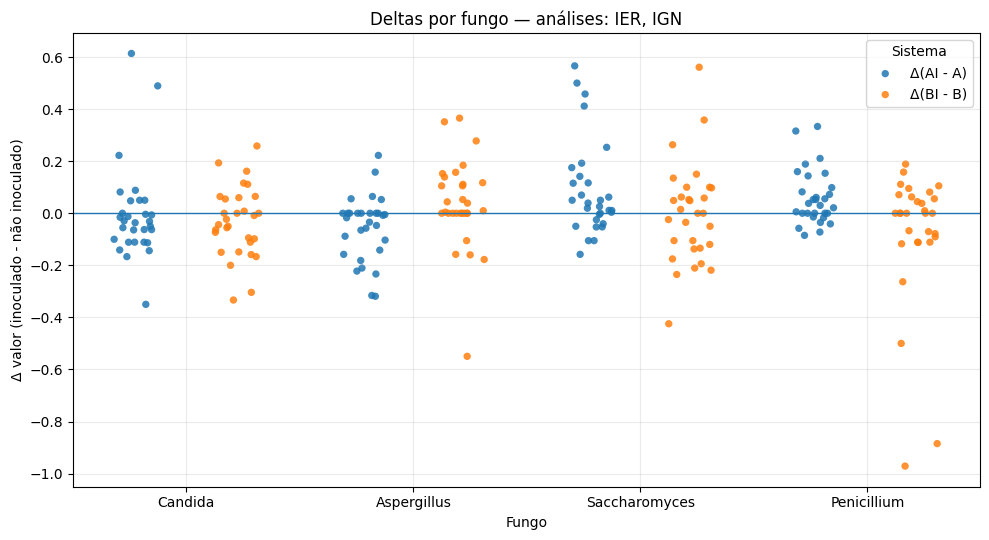

In [27]:

fig, ax = plot_fungo_strip( analises=["IGN", "IER"], bases=("A", "B"))
fig.savefig( f"scatter.png", dpi=300, bbox_inches="tight")
fig.savefig( f"scatter.pdf", bbox_inches="tight")

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_fungo_boxplot_split(
    *,
    analises: list[str],
    bases: tuple[str, str] = ("A", "B"),
    fungos_order: list[str] | None = None,
    y_col: str = "valor",
    pair_keys: tuple[str, ...] = ("concentracao", "dia"),
    agg: str = "mean",          # 'mean' or 'median' before delta
    dodge: float = 0.18,
    box_width: float = 0.30,
    show: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Boxplot per fungus, split by delta type:
      - Two boxes per fungus: Δ(AI-A) and Δ(BI-B)
      - Deltas are computed by pairing rows within (fungo, analise, concentracao, dia) by default.
      - All selected analyses are pooled together.

    Required columns: fungo, sistema, analise, valor, plus pair_keys.
    """
    required = {"fungo", "sistema", "analise", y_col, *pair_keys}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    if not analises:
        raise ValueError("analises must be a non-empty list.")

    d = df.copy()
    d["fungo"] = d["fungo"].astype(str).str.strip()
    d["sistema"] = d["sistema"].astype(str).str.strip()
    d["analise"] = d["analise"].astype(str).str.strip()
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    wanted = {str(a).strip() for a in analises}

    needed_systems: list[str] = []
    for b in bases:
        needed_systems.extend([b, f"{b}I"])

    d = d[
        d["analise"].isin(wanted)
        & d["sistema"].isin(needed_systems)
        & d[y_col].notna()
    ].copy()

    if d.empty:
        raise ValueError(
            f"No rows after filtering to analises={sorted(wanted)} and sistemas={needed_systems}."
        )

    # Normalize common fungus spelling variants (practical)
    def norm_fungo(s: str) -> str:
        lo = s.lower()
        if "aspergill" in lo: return "Aspergillus"
        if "saccharom" in lo: return "Saccharomyces"
        if "penicill" in lo: return "Penicillium"
        if "candida" in lo: return "Candida"
        return s

    d["fungo_norm"] = d["fungo"].map(norm_fungo)

    # Collapse replicates so each (fungo, analise, pair_keys..., sistema) is single-valued
    group_cols = ["fungo_norm", "analise", *pair_keys, "sistema"]

    if agg == "mean":
        d_agg = d.groupby(group_cols, observed=True)[y_col].mean().reset_index()
    elif agg == "median":
        d_agg = d.groupby(group_cols, observed=True)[y_col].median().reset_index()
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Pivot then compute deltas
    idx_cols = ["fungo_norm", "analise", *pair_keys]
    pv = d_agg.pivot_table(index=idx_cols, columns="sistema", values=y_col, aggfunc="first")

    delta_frames = []
    for b in bases:
        inoc = f"{b}I"
        if b not in pv.columns or inoc not in pv.columns:
            continue
        delta = (pv[inoc] - pv[b]).dropna()
        if delta.empty:
            continue
        tmp = delta.reset_index()
        tmp.rename(columns={tmp.columns[-1]: "delta"}, inplace=True)  # last col is the delta values
        tmp["delta_base"] = b
        delta_frames.append(tmp)

    if not delta_frames:
        raise ValueError(
            "Could not compute any deltas. Likely missing paired systems (A and AI, or B and BI) "
            "for the same (fungo, analise, concentracao, dia)."
        )

    dd = pd.concat(delta_frames, ignore_index=True)

    # Category order
    if fungos_order is None:
        preferred = ["Candida", "Aspergillus", "Saccharomyces", "Penicillium"]
        present = list(dict.fromkeys(dd["fungo_norm"].tolist()))
        fungos_order = [f for f in preferred if f in present] + [f for f in present if f not in preferred]

    base_pos = np.arange(1, len(fungos_order) + 1)
    positions = {
        bases[0]: base_pos - dodge,
        bases[1]: base_pos + dodge,
    }

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = {bases[0]: "C0", bases[1]: "C1"}

    for b in bases:
        series_list = [
            dd.loc[(dd["fungo_norm"].eq(f)) & (dd["delta_base"].eq(b)), "delta"].to_numpy(dtype=float)
            for f in fungos_order
        ]

        bp = ax.boxplot(
            series_list,
            positions=positions[b],
            widths=box_width,
            patch_artist=True,
            showfliers=True,
            manage_ticks=False,
        )

        for box in bp["boxes"]:
            box.set_facecolor(colors[b])
            box.set_alpha(0.35)

    ax.axhline(0, linewidth=1)
    ax.set_xticks(base_pos)
    ax.set_xticklabels(fungos_order)
    ax.set_xlabel("Fungo")
    ax.set_ylabel(f"Δ {y_col} (inoculado - não inoculado)")
    ax.set_title(f"Boxplot de deltas por fungo — análises: {', '.join(sorted(wanted))}")
    ax.grid(True, alpha=0.25, axis="y")

    ax.legend(
        handles=[
            Patch(facecolor=colors[b], alpha=0.35, label=f"Δ({b}I - {b})")
            for b in bases
        ],
        title="Delta",
        loc="best",
        frameon=True,
    )

    fig.tight_layout()
    if show:
        plt.show()

    return fig, ax


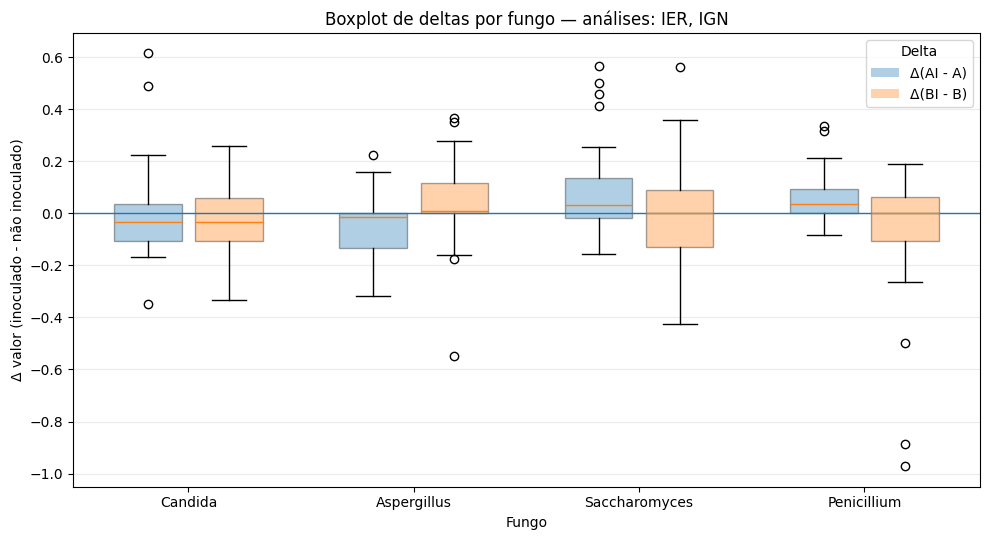

In [33]:
fig, ax = plot_fungo_boxplot_split( analises=["IGN", "IER"], bases=("A", "B"))
